首先先讀取一下檔案,看一下檔案長甚麼樣子以及裡面有甚麼

In [53]:
import pandas as pd
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',header=None)
data.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num','marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

data.head

<bound method NDFrame.head of        age          workclass  fnlwgt    education  education-num  \
0       39          State-gov   77516    Bachelors             13   
1       50   Self-emp-not-inc   83311    Bachelors             13   
2       38            Private  215646      HS-grad              9   
3       53            Private  234721         11th              7   
4       28            Private  338409    Bachelors             13   
...    ...                ...     ...          ...            ...   
32556   27            Private  257302   Assoc-acdm             12   
32557   40            Private  154374      HS-grad              9   
32558   58            Private  151910      HS-grad              9   
32559   22            Private  201490      HS-grad              9   
32560   52       Self-emp-inc  287927      HS-grad              9   

            marital-status          occupation    relationship    race  \
0            Never-married        Adm-clerical   Not-in-family   Wh

In [2]:
#檢查數據裡是否有檔案缺失
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


檢查完畢,沒有數值缺失!

將 nominal and ordinal data 轉換成 numerical data 因為決策樹 in sklearn package 只接受 numerical data. 

In [60]:
#用dummies進行轉換
Bruh_data = pd.get_dummies(data[ ['workclass','education','marital-status','occupation','relationship','race','sex','native-country'] ])

Bruh_data = Bruh_data.astype(int)
Bruh_data.head(10)


,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 10th,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
8,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


刪除舊的資料框架並創建一個包含 Bruh_data 的新資料框架

In [61]:
df = data.drop(['workclass','education','marital-status','occupation','relationship','race','sex','native-country'], axis=1)
df = pd.concat([df, Bruh_data], axis=1)
df

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,77516,13,2174,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,83311,13,0,0,13,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,38,215646,9,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,234721,7,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,338409,13,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32557,40,154374,9,0,0,40,>50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32558,58,151910,9,0,0,40,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32559,22,201490,9,0,0,20,<=50K,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [62]:
#將資料框架設置為 Y 和 X，用於訓練模型
Y = df['income']
X = df.drop(['income'],axis=1)

將資料集分為訓練集與測試集

In [6]:
from sklearn.model_selection import train_test_split

#將資料集分成 80% 的訓練集和 20% 的測試集
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1)

設定 Hyperparameters

In [7]:
from sklearn.tree import DecisionTreeClassifier


tree_clf_1 = DecisionTreeClassifier(max_depth = 4, min_samples_leaf = 2)

tree_clf_2 = DecisionTreeClassifier(max_depth = 10, min_samples_split = 2, min_samples_leaf = 2)

tree_clf_2 = DecisionTreeClassifier(max_depth = 3, min_samples_split = 2, min_samples_leaf = 1)

我認為自己會做三個實驗來找到最佳結果並與其他超參數設置進行比較

訓練分類器並測試分類器

In [8]:
# 訓練模型
clf_train_1 = tree_clf_1.fit(X_train,Y_train)
clf_train_2 = tree_clf_2.fit(X_train,Y_train)
clf_train_3 = tree_clf_2.fit(X_train,Y_train)

In [9]:
#對訓練集和測試集進行預測
Y_pred_train_1 = clf_train_1.predict(X_train)
Y_pred_1 = clf_train_1.predict(X_test)

Y_pred_train_2 = clf_train_2.predict(X_train)
Y_pred_2 = clf_train_2.predict(X_test)

Y_pred_train_3 = clf_train_3.predict(X_train)
Y_pred_3 = clf_train_3.predict(X_test)


記錄一下分類準確率

In [10]:
from sklearn.metrics import accuracy_score

# the classification accuracy for both training dataset and testing dataset.
print('Accuracy1 on train data is %.5f' % (accuracy_score(Y_train, Y_pred_train_1)))
print('Accuracy1 on test data is %.5f' % (accuracy_score(Y_test, Y_pred_1)))
print('-----------------------------------------')
print('Accuracy2 on train data is %.5f' % (accuracy_score(Y_train, Y_pred_train_2)))
print('Accuracy2 on test data is %.5f' % (accuracy_score(Y_test, Y_pred_2)))
print('-----------------------------------------')
print('Accuracy3 on train data is %.5f' % (accuracy_score(Y_train, Y_pred_train_3)))
print('Accuracy3 on test data is %.5f' % (accuracy_score(Y_test, Y_pred_3)))

Accuracy1 on train data is 0.84402
Accuracy1 on test data is 0.84477
-----------------------------------------
Accuracy2 on train data is 0.84363
Accuracy2 on test data is 0.84493
-----------------------------------------
Accuracy3 on train data is 0.84363
Accuracy3 on test data is 0.84493


從這三個結果可以得知
#模型1 有最佳的Accuracy
#模型2 是因為增加最大深度和增加最小節點分裂樣本數導致準確率比模型1低
#模型3 是因為降低最大深度和減少最小葉子節點樣本數導致準確率比模型1低
從此實驗會發現模型1是實驗中最好的模型因為最大深度沒有過深而且訓練和測試的準確率幾乎相等!

In [11]:
pip install pydotplus

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


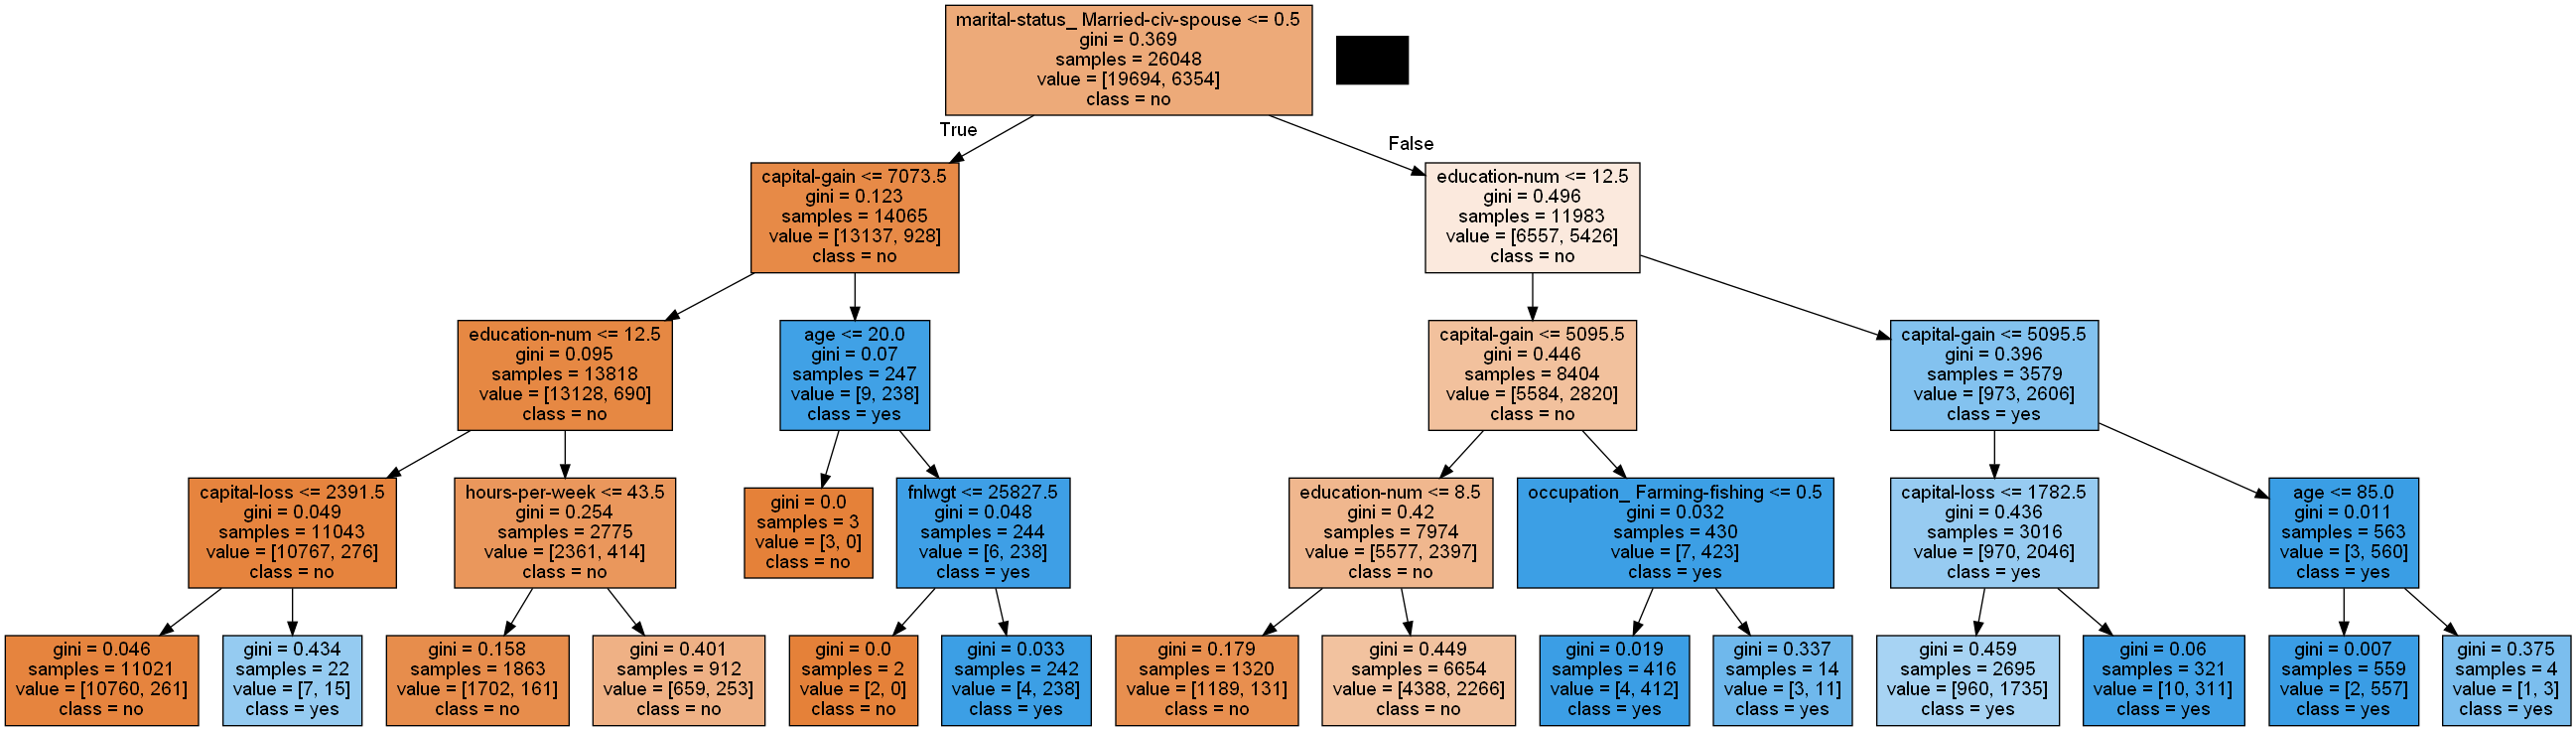

In [13]:
from sklearn import tree
import pydotplus 
from IPython.display import Image

# print the charts of decision tree from model1 which best Accuracy   
dot_data = tree.export_graphviz(clf_train_1, feature_names=X.columns, class_names=['no', 'yes'], filled=True, 
                                out_file=None) 
graph = pydotplus.graph_from_dot_data(dot_data) 
Image(graph.create_png())

根據上個測試結果發現模型1在訓練集有較高的準確率(值為0.84402)且在測試集有高的準確率(值為0.84477),因此我選擇用此模型1來畫決策樹圖表圖


實驗1

使用原始數據應用 GridSearchCV 來探索最佳的超參數設置。

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import numpy as np

# 定義模型
model = DecisionTreeClassifier()

# 定義評估方式：使用重複分層 K 折交叉驗證
cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=5, random_state=1)

# 定義參數搜索空間
space = {
    'criterion': ['gini', 'entropy'],
    'max_leaf_nodes': np.arange(2, 10),
    'min_samples_split': np.arange(2, 6),
    'min_samples_leaf': np.arange(1, 3)
}

# 定義 GridSearchCV 尋找最佳超參數組合
search = GridSearchCV(model, space, scoring='accuracy', n_jobs=-1, cv=cv)

# 執行搜索
result = search.fit(X, Y)  # X 是特徵數據，Y 是目標標籤

# 顯示最佳結果
print('Best Score: %s' % result.best_score_)
print('Best Hyperparameters: %s' % result.best_params_)


Best Score: 0.8463499124462254
Best Hyperparameters: {'criterion': 'gini', 'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [31]:
# 從 GridSearchCV 中調用最佳模型。
best_model = result.best_estimator_

# 使用最佳模型對訓練集和測試集進行預測。
Y_pred_best_model_train = best_model.predict(X_train)
Y_pred_best_model_test = best_model.predict(X_test)

print('Accuracy on train data is %.5f' % (accuracy_score(Y_train, Y_pred_best_model_train)))
print('Accuracy on test data is %.5f' % (accuracy_score(Y_test, Y_pred_best_model_test)))

Accuracy on train data is 0.84866
Accuracy on test data is 0.85015


在此實驗1,使用了GridSearchCV 來探索最佳的超參數設置。
#根據測試我發現最佳的超參數設置是'criterion': 'gini','max_leaf_nodes': 9,'min_samples_leaf': 1,'min_samples_split': 2
這組超參數設置的準確率比我先前弄的還要高,訓練集的準確率為0.84866,測試集的準確率為0.85015

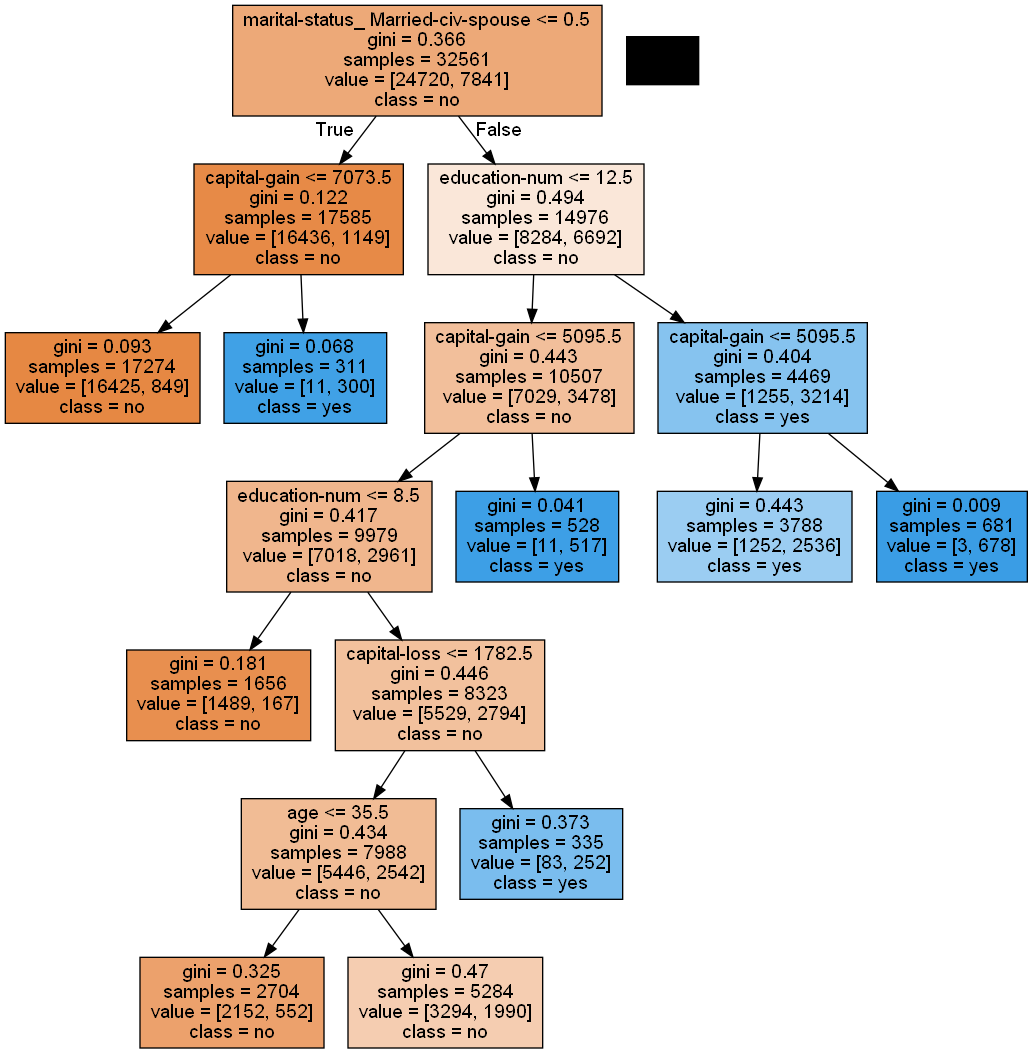

In [32]:
# 顯示最佳模型的決策樹圖表。
dot_data = tree.export_graphviz(best_model, feature_names=X.columns, class_names=['no', 'yes'], filled=True, 
                                out_file=None) 
graph = pydotplus.graph_from_dot_data(dot_data) 
Image(graph.create_png())

實驗2


實驗2是在使用轉換技術（例如 z-score）和丟棄缺失值來設定一種新的前處理方法。

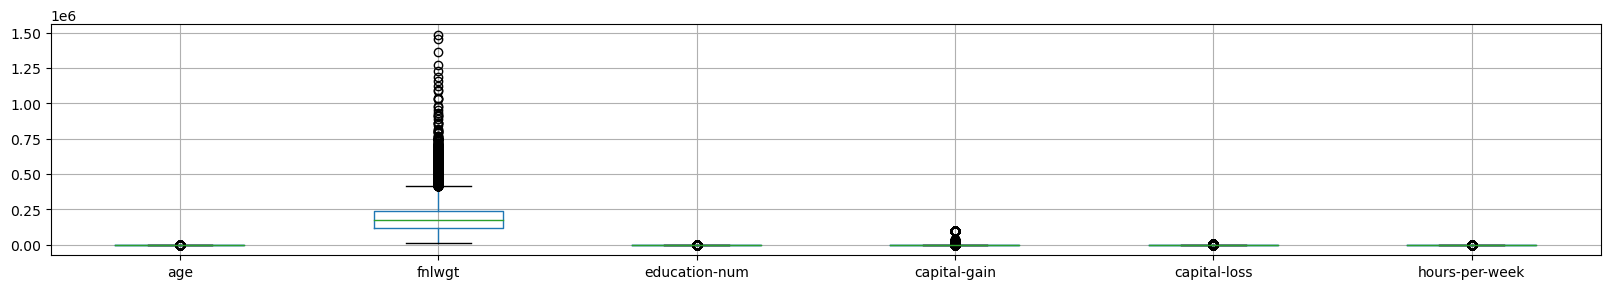

In [14]:
import matplotlib.pyplot as plt

# 使用箱形圖（box plot）檢視變量數據。
%matplotlib inline

data2 = data.drop(['workclass','education','marital-status','occupation','relationship','race','sex','native-country'],axis=1)

data2.boxplot(figsize=(20,3))
plt.show()

In [15]:
# 選擇僅原始數值型資料。 

data2 = data2[['age','fnlwgt', 'education-num','capital-gain', 'capital-loss', 'hours-per-week', 'income']]
data2 

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,77516,13,2174,0,40,<=50K
1,50,83311,13,0,0,13,<=50K
2,38,215646,9,0,0,40,<=50K
3,53,234721,7,0,0,40,<=50K
4,28,338409,13,0,0,40,<=50K
...,...,...,...,...,...,...,...
32556,27,257302,12,0,0,38,<=50K
32557,40,154374,9,0,0,40,>50K
32558,58,151910,9,0,0,40,<=50K
32559,22,201490,9,0,0,20,<=50K


In [18]:
import pandas as pd
from scipy.stats import zscore

# 假設 data2 是包含原始數據的 DataFrame
# 選擇只含有數值型資料的欄位（不包括 'income'）
data2_numerical = data2[['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']]

# 將數值型欄位轉換為數值型資料
data2_numerical = data2_numerical.apply(pd.to_numeric, errors='coerce')

# 計算 Z-score，並將結果保存到 Z2 中
Z2 = zscore(data2_numerical)

# 打印前 5 個 Z-score
print(Z2[0:5])


        age    fnlwgt  education-num  capital-gain  capital-loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours-per-week  
0       -0.035429  
1       -2.222153  
2       -0.035429  
3       -0.035429  
4       -0.035429  


In [19]:
import numpy as np
print('Number of rows before discarding outliers = %d' % (Z2.shape[0]))

#這段程式碼選擇了刪除 Z 值大於 3或小於等於 -3 的列的結果。
Z2 = Z2.where((Z2 > -3) & (Z2 <= 3), np.NaN)
#Z2 = Z2[(Z2 > -3) & (Z2 <= 3)].dropna()

print('Number of rows after replace Z-scores outside the range [-3, 3] with NaN =', Z2.shape[0])

Number of rows before discarding outliers = 32561
Number of rows after replace Z-scores outside the range [-3, 3] with NaN = 32561


In [20]:
# keep data to dataframe2 include Z2, Bruh_data , Y
df2 = pd.concat([Z2, one_hot_data,Y], axis=1)
df2

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,0,0,0,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,-0.849080,0.639741,0.746039,-0.145920,-0.21666,-0.197409,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
32557,0.103983,-0.335433,-0.420060,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,>50K
32558,1.423610,-0.358777,-0.420060,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
32559,-1.215643,0.110960,-0.420060,-0.145920,-0.21666,-1.655225,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K


In [21]:
# 刪除具有缺失值（NaN）的數據。
df2 = df2.dropna()

print('Number of rows after discarding missing values or removing Z-scores outside the range [-3, 3]  = %d' % (df2.shape[0]))

Number of rows after discarding missing values or removing Z-scores outside the range [-3, 3]  = 29828


In [22]:
# 設定 dataframe2 的 Y2 和 X2 用於訓練模型。
Y2 = df2['income']
X2 = df2.drop(['income'],axis=1)

In [23]:
# 將數據集分割為訓練集和測試集。
X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, Y2, test_size=0.2, random_state=1)

In [33]:
# 使用第一個實驗中的最佳模型。
best_model = result.best_estimator_

In [34]:
# 訓練模型並對訓練集和測試集進行預測。
clf2_train = best_model.fit(X2_train,Y2_train)

Y2_pred_train = clf2_train.predict(X2_train)
Y2_pred = clf2_train.predict(X2_test)

print('Accuracy on train data is %.5f' % (accuracy_score(Y2_train, Y2_pred_train)))
print('Accuracy on test data is %.5f' % (accuracy_score(Y2_test, Y2_pred)))

Accuracy on train data is 0.84817
Accuracy on test data is 0.84395


根據實驗2的結果可以得知:
    #1. 使用 z-score 對數值型數據進行轉換（刪除 Z-score 超出範圍 [-3, 3] 的值），對名義和序數數據使用 Bruh_data 進行處理，導致數據量從 32561 減少到 29828。
    #2 從實驗2可以得出訓練集準確率為0.84817, 測試集的準確率為0.84395,比實驗1的準確率還低

實驗3

實驗3是在設定一種新的預處理方法，方法是刪除具有未知數據的特徵所在的行，並使用轉換技術（z-score）並且丟棄缺失值（未知數據）。

In [42]:
import numpy as np

data3 = data.replace('unknown',np.NaN)

print('Number of instances = %d' % (data.shape[0]))
print('Number of attributes = %d' % (data.shape[1]))

print('Number of missing values:')
for col in data.columns:
    print('\t%s: %d' % (col,data[col].isna().sum()))

Number of instances = 32561
Number of attributes = 15
Number of missing values:
	age: 0
	workclass: 0
	fnlwgt: 0
	education: 0
	education-num: 0
	marital-status: 0
	occupation: 0
	relationship: 0
	race: 0
	sex: 0
	capital-gain: 0
	capital-loss: 0
	hours-per-week: 0
	native-country: 0
	income: 0


In [43]:
# 保留新的 'income'（假設 'income' 是目標變數）
Y2 = data['income']

# 使用 Bruh_data Encoding 處理類別型特徵
# 選擇要進行 Bruh_data Encoding 的類別型欄位
categorical_cols = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country']

# 對類別型欄位進行 Bruh_data Encoding
Bruh_data = pd.get_dummies(data[categorical_cols])

# 將 Bruh_data Encoding 後的資料類型轉換為整數型
Bruh_data = Bruh_data.astype(int)
Bruh_data

,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 10th,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32557,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32558,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
32559,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [44]:
data3 = data3[['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']]

# 計算 Data2 的 Z-score，並將其命名為 Z2。
Z3 = zscore(data3)

print('Number of rows before discarding outliers = %d' % (Z3.shape[0]))

#這段程式碼選擇了刪除 Z-score 大於 3或小於等於 -3 的列的結果。
Z3 = Z3.where((Z3 > -3) & (Z3 <= 3), np.NaN)

print('Number of rows after replace Z-scores outside the range [-3, 3] with NaN =', Z3.shape[0])

Number of rows before discarding outliers = 32561
Number of rows after replace Z-scores outside the range [-3, 3] with NaN = 32561


In [63]:
# keep data to dataframe2 include Z2, Bruh_data , Y
df3 = pd.concat([Z3, Bruh_data,Y2], axis=1)
df3

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,...,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia,income
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,0,0,0,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,-0.849080,0.639741,0.746039,-0.145920,-0.21666,-0.197409,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
32557,0.103983,-0.335433,-0.420060,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,>50K
32558,1.423610,-0.358777,-0.420060,-0.145920,-0.21666,-0.035429,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K
32559,-1.215643,0.110960,-0.420060,-0.145920,-0.21666,-1.655225,0,0,0,0,...,0,0,0,0,0,0,1,0,0,<=50K


In [47]:
# 刪除具有缺失值（NaN）的數據。
df3 = df3.dropna()

print('Number of rows after discarding missing values or removing Z-scores outside the range [-3, 3]  = %d' % (df3.shape[0]))

Number of rows after discarding missing values or removing Z-scores outside the range [-3, 3]  = 29828


In [49]:
# 將 dataframe3 設置為 Y3 和 X3 以供訓練模型使用。
Y3 = df3['income']
X3 = df3.drop(['income'],axis=1)

# 將數據集分割為訓練集和測試集。
X3_train, X3_test, Y3_train, Y3_test = train_test_split(
    X3, Y3, test_size=0.2, random_state=1)

In [50]:
# 使用第一個實驗中的最佳模型。
best_model = result.best_estimator_

# 訓練模型並對訓練集和測試集進行預測。

clf3_train = best_model.fit(X3_train,Y3_train)

Y3_pred_train = clf3_train.predict(X3_train)
Y3_pred = clf3_train.predict(X3_test)

print('Accuracy on train data is %.5f' % (accuracy_score(Y3_train, Y3_pred_train)))
print('Accuracy on test data is %.5f' % (accuracy_score(Y3_test, Y3_pred)))

Accuracy on train data is 0.84817
Accuracy on test data is 0.84395


根據實驗3可以得知:
    #1使用 z-score 對數值型數據進行轉換（刪除 Z-score 超出範圍 [-3, 3] 的值），對名義和序數數據使用 Bruh_data 進行處理，導致數據量從32561降低成29828
    #2實驗3的訓練集準確率為0.84817,測試集的準確率為0.84395,此結果跟實驗2相同

結論:
    #1在手動設置超參數的實驗中，我們發現訓練集和測試集的準確率非常高。最佳超參數為 max_depth=4、min_samples_leaf=2，在此實驗中訓練集準確率為 0.84402，測試集準確率為 0.84477。
    #2在實驗1中，使用 GridSearchCV 探索最佳的超參數設置，我們發現最佳超參數為 criterion='gini'、max_leaf_nodes=9、min_samples_leaf=1、min_samples_split=2，最佳分數為 0.84634。這組超參數的準確率比我們手動設置的要高，訓練集準確率為 0.84866，測試集準確率為 0.85015。
    #3在實驗2中，使用轉換技術（z-score）並刪除超出範圍 [-3, 3] 的 Z-score，我們發現訓練集準確率為 0.84817，測試集準確率為 0.84395，比實驗1的準確率還低，可能是因為刪除到了重要的數據導致準確率降低了。
    #4在實驗3中，刪除具有未知數據的特徵所在的行，使用轉換技術（z-score），我們發現訓練集準確率為 0.84817，測試集準確率為 0.84395，跟實驗2的準確率一樣，因為這些數據中含有更多未知數據。刪除數據導致訓練模型的樣本數減少，並且由於缺乏重要數據來訓練模型，模型性能有所降低，但在這種情況下，準確率仍然很高且可接受。